<a href="https://colab.research.google.com/github/lizbettymoralesf-hub/demand-forecasting-machine-learning/blob/main/notebooks/01_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Demanda mediante Machine Learning

**Proyecto de Supply Chain Analytics | Python · Machine Learning · XGBoost**

Este proyecto desarrolla un modelo de predicción de demanda para estimar las ventas diarias por tienda y familia de productos de Corporación Favorita.

Se utilizan más de 3 millones de registros históricos de ventas junto con información de promociones, calendario, feriados, características de las tiendas y precio del petróleo.

El proyecto incluye:

- Análisis exploratorio de datos.
- Ingeniería de variables temporales.
- Construcción de un baseline estacional.
- Modelos Random Forest y XGBoost.
- Validación cronológica de 16 días.
- Backtesting mediante múltiples ventanas temporales.
- Análisis de errores por tienda y familia de productos.
- Predicción de demanda para un horizonte futuro de 16 días.

**Métrica principal:** RMSLE (Root Mean Squared Logarithmic Error).

##1. Objetivo del proyecto

El objetivo es desarrollar un modelo capaz de predecir las ventas diarias para cada combinación de tienda y familia de productos.

Desde una perspectiva de Supply Chain, una estimación más precisa de la demanda puede apoyar decisiones relacionadas con planificación de inventarios, reposición, abastecimiento y disponibilidad de productos.

El horizonte de predicción utilizado es de **16 días**, coincidiendo con el período definido en el conjunto de prueba.

##2. Configuración y carga de datos

In [392]:
import os
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [393]:
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get(
    "KAGGLE_API_TOKEN"
)

In [394]:
DATA_PATH = "/content/data/raw"

df_train = pd.read_csv(f"{DATA_PATH}/train.csv")
df_test = pd.read_csv(f"{DATA_PATH}/test.csv")
df_stores = pd.read_csv(f"{DATA_PATH}/stores.csv")
df_holidays = pd.read_csv(f"{DATA_PATH}/holidays_events.csv")
df_oil = pd.read_csv(f"{DATA_PATH}/oil.csv")
df_transactions = pd.read_csv(f"{DATA_PATH}/transactions.csv")
sample_submission = pd.read_csv(
    f"{DATA_PATH}/sample_submission.csv"
)

date_datasets = [
    df_train,
    df_test,
    df_holidays,
    df_oil,
    df_transactions
]

for dataset in date_datasets:
    dataset["date"] = pd.to_datetime(dataset["date"])

print("Datasets cargados correctamente.")
print(f"Train:        {df_train.shape}")
print(f"Test:         {df_test.shape}")
print(f"Stores:       {df_stores.shape}")
print(f"Holidays:     {df_holidays.shape}")
print(f"Oil:          {df_oil.shape}")
print(f"Transactions: {df_transactions.shape}")

Datasets cargados correctamente.
Train:        (3000888, 6)
Test:         (28512, 5)
Stores:       (54, 5)
Holidays:     (350, 6)
Oil:          (1218, 2)
Transactions: (83488, 3)


## 3. Exploración y calidad de los datos

In [395]:
print("Shape train:", df_train.shape)

display(df_train.head())

display(
    df_train.describe(include="all").T
)

Shape train: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,3000888.0,NaN,NaN,NaN,1500443.5,0.0,750221.75,1500443.5,2250665.25,3000887.0,866281.891642
date,3000888,NaN,NaN,NaN,2015-04-24 08:27:04.703088384,2013-01-01 00:00:00,2014-02-26 18:00:00,2015-04-24 12:00:00,2016-06-19 06:00:00,2017-08-15 00:00:00,NaN
store_nbr,3000888.0,NaN,NaN,NaN,27.5,1.0,14.0,27.5,41.0,54.0,15.585787
family,3000888,33,AUTOMOTIVE,90936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,3000888.0,NaN,NaN,NaN,357.775749,0.0,0.0,11.0,195.84725,124717.0,1101.997721
onpromotion,3000888.0,NaN,NaN,NaN,2.60277,0.0,0.0,0.0,0.0,741.0,12.218882


In [396]:
quality_summary = pd.DataFrame({
    "missing_values": df_train.isnull().sum(),
    "duplicates": [
        df_train.duplicated().sum()
        if col == df_train.columns[0]
        else np.nan
        for col in df_train.columns
    ]
})

display(quality_summary)

print(
    "Filas duplicadas:",
    df_train.duplicated().sum()
)

print(
    "Ventas iguales a cero:",
    (df_train["sales"] == 0).sum()
)

print(
    "Porcentaje ventas cero:",
    round(
        (df_train["sales"] == 0).mean() * 100,
        2
    ),
    "%"
)

,missing_values,duplicates
id,0,0.0
date,0,NaN
store_nbr,0,NaN
family,0,NaN
sales,0,NaN
onpromotion,0,NaN


Filas duplicadas: 0
Ventas iguales a cero: 939130
Porcentaje ventas cero: 31.3 %


In [397]:
print(
    "Rango temporal:",
    df_train["date"].min(),
    "→",
    df_train["date"].max()
)

print(
    "Fechas únicas:",
    df_train["date"].nunique()
)

print(
    "Tiendas:",
    df_train["store_nbr"].nunique()
)

print(
    "Familias:",
    df_train["family"].nunique()
)

Rango temporal: 2013-01-01 00:00:00 → 2017-08-15 00:00:00
Fechas únicas: 1684
Tiendas: 54
Familias: 33


In [398]:
expected_dates = pd.date_range(
    df_train["date"].min(),
    df_train["date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    df_train["date"].unique()
)

print("Fechas faltantes:")
print(missing_dates)

Fechas faltantes:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


### Principales hallazgos de calidad

El conjunto de entrenamiento contiene más de 3 millones de observaciones y no presenta valores nulos ni filas duplicadas.

La información está registrada a nivel de fecha, tienda y familia de productos. Se identificaron 54 tiendas y 33 familias durante el período comprendido entre enero de 2013 y agosto de 2017.

Aproximadamente el 31% de las observaciones presenta ventas iguales a cero, lo que indica que parte de la demanda es intermitente.

También se identificaron cuatro fechas ausentes en la serie, correspondientes al 25 de diciembre de 2013, 2014, 2015 y 2016. Estas fechas no se imputan automáticamente como ventas cero.

## 4. Análisis de la demanda

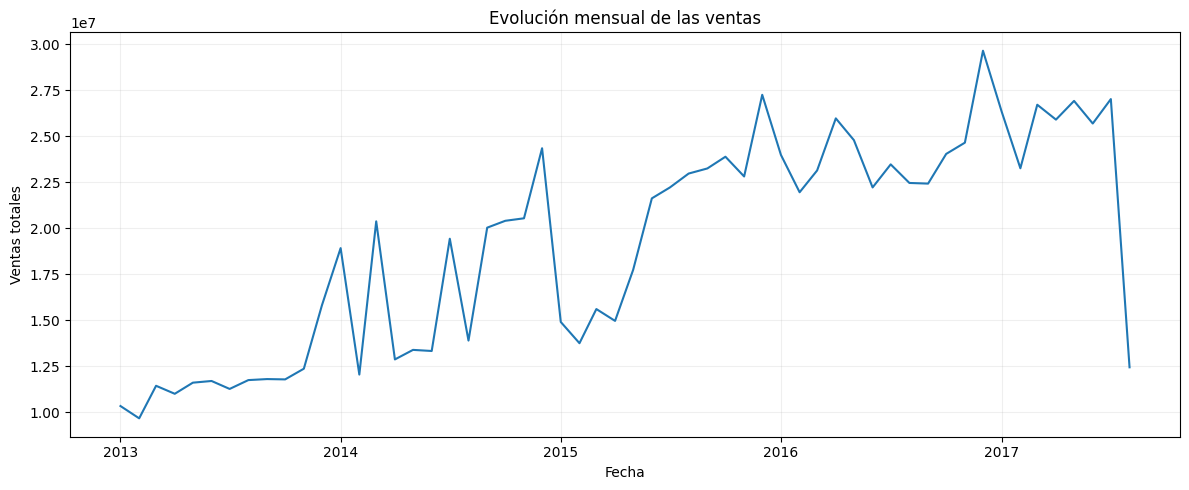

In [399]:
monthly_sales = (
    df_train
    .set_index("date")
    .resample("MS")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales"]
)

plt.title("Evolución mensual de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas totales")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Interpretación:** La serie presenta una tendencia general de crecimiento junto con fluctuaciones temporales importantes. El año 2017 debe interpretarse con cautela, ya que el conjunto de entrenamiento finaliza el 15 de agosto.

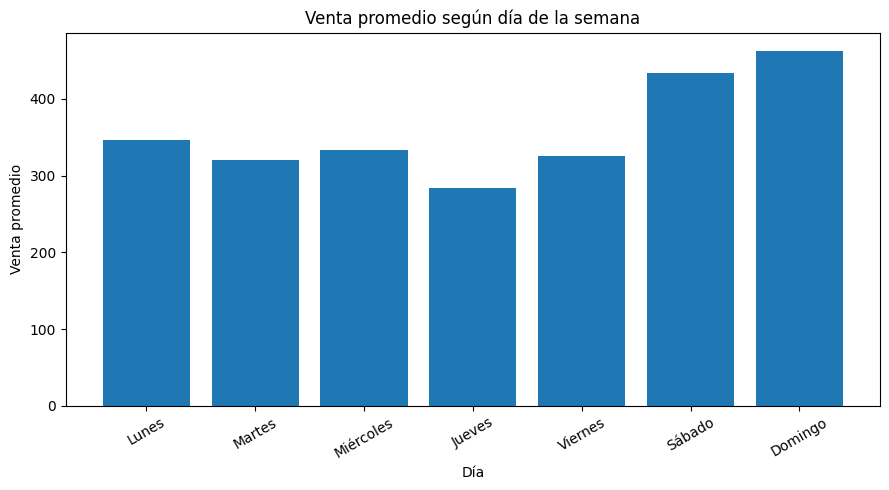

In [400]:
weekday_sales = (
    df_train
    .assign(
        day_of_week=df_train["date"].dt.dayofweek
    )
    .groupby("day_of_week")["sales"]
    .mean()
    .reindex(range(7))
)

weekday_names = [
    "Lunes",
    "Martes",
    "Miércoles",
    "Jueves",
    "Viernes",
    "Sábado",
    "Domingo"
]

plt.figure(figsize=(9, 5))

plt.bar(
    weekday_names,
    weekday_sales.values
)

plt.title("Venta promedio según día de la semana")
plt.xlabel("Día")
plt.ylabel("Venta promedio")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa una estacionalidad semanal clara. La demanda aumenta durante el fin de semana, alcanzando su mayor nivel promedio los domingos, mientras que los jueves presentan el menor nivel.

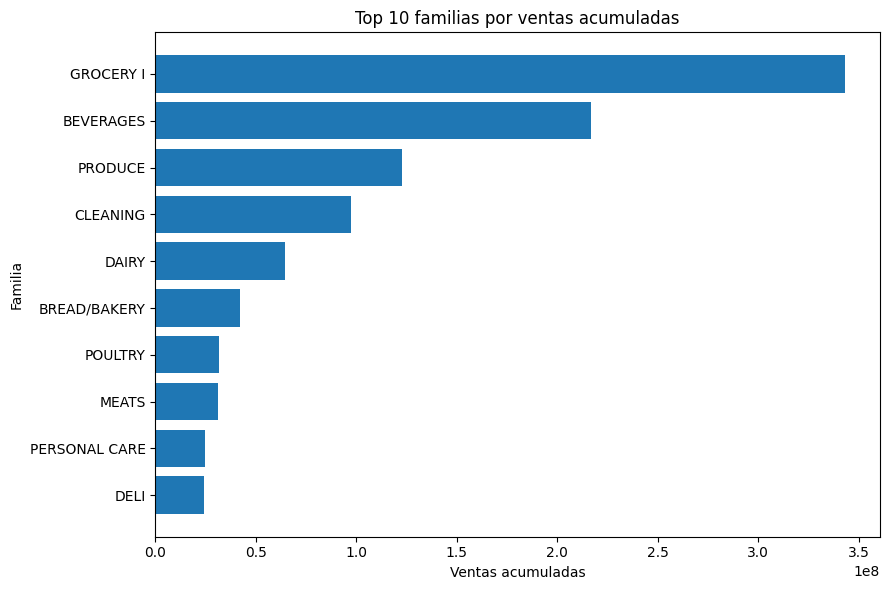

In [401]:
top_families = (
    df_train
    .groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_families.index,
    top_families.values
)

plt.title("Top 10 familias por ventas acumuladas")
plt.xlabel("Ventas acumuladas")
plt.ylabel("Familia")

plt.tight_layout()
plt.show()

**Interpretación:** La demanda se concentra principalmente en categorías como Grocery I, Beverages, Produce y Cleaning. Las diferencias entre familias justifican incorporar la categoría de producto como variable del modelo y analizar posteriormente el error de predicción por segmento.

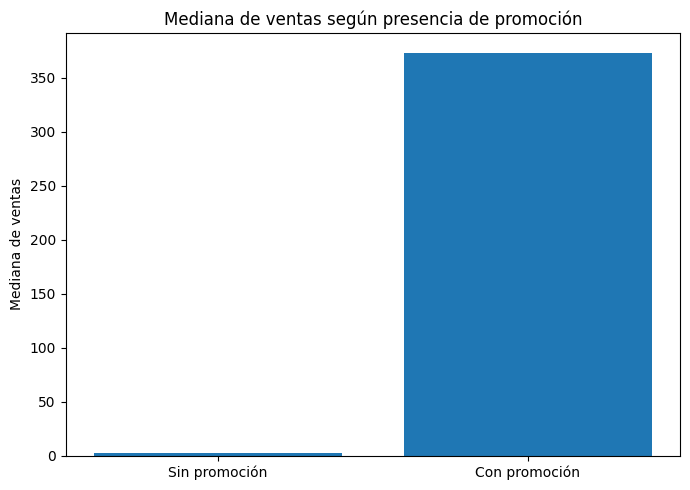

In [402]:
promotion_analysis = (
    df_train
    .assign(
        promotion=np.where(
            df_train["onpromotion"] > 0,
            "Con promoción",
            "Sin promoción"
        )
    )
    .groupby("promotion")["sales"]
    .median()
    .reindex([
        "Sin promoción",
        "Con promoción"
    ])
)

plt.figure(figsize=(7, 5))

plt.bar(
    promotion_analysis.index,
    promotion_analysis.values
)

plt.title("Mediana de ventas según presencia de promoción")
plt.ylabel("Mediana de ventas")

plt.tight_layout()
plt.show()

**Interpretación:** Las observaciones asociadas a promociones presentan niveles de venta considerablemente superiores. Esta relación es descriptiva y no implica necesariamente causalidad, pero indica que `onpromotion` contiene información potencialmente relevante para el forecasting.

## 5. Integración de fuentes de información

### Información de las tiendas

El dataset de tiendas incorpora características estructurales como ciudad, provincia, tipo de tienda y cluster. Estas variables permiten representar diferencias entre establecimientos que podrían influir en sus patrones de demanda.

In [403]:
df = df_train.merge(
    df_stores,
    on="store_nbr",
    how="left"
)

print("Dimensiones después del merge:", df.shape)

print("\nValores faltantes:")
print(
    df[["city", "state", "type", "cluster"]]
    .isnull()
    .sum()
)

Dimensiones después del merge: (3000888, 10)

Valores faltantes:
city       0
state      0
type       0
cluster    0
dtype: int64


### Feriados y eventos

Los eventos pueden tener alcance nacional, regional o local. Debido a que una misma fecha puede contener múltiples eventos, no se realiza un merge directo únicamente por fecha, ya que podría generar duplicación de observaciones.

En su lugar, se construyen indicadores binarios respetando el alcance geográfico de cada evento.

In [404]:
holidays_effective = (
    df_holidays[
        df_holidays["transferred"] == False
    ]
    .copy()
)

national_holidays = holidays_effective[
    holidays_effective["locale"] == "National"
]

regional_holidays = holidays_effective[
    holidays_effective["locale"] == "Regional"
]

local_holidays = holidays_effective[
    holidays_effective["locale"] == "Local"
]

national_dates = set(
    national_holidays["date"]
)

regional_keys = set(
    zip(
        regional_holidays["date"],
        regional_holidays["locale_name"]
    )
)

local_keys = set(
    zip(
        local_holidays["date"],
        local_holidays["locale_name"]
    )
)

In [405]:
df["national_event"] = (
    df["date"]
    .isin(national_dates)
    .astype("int8")
)

df["regional_event"] = [
    int((date, state) in regional_keys)
    for date, state in zip(
        df["date"],
        df["state"]
    )
]

df["local_event"] = [
    int((date, city) in local_keys)
    for date, city in zip(
        df["date"],
        df["city"]
    )
]

df["is_event"] = (
    (df["national_event"] == 1) |
    (df["regional_event"] == 1) |
    (df["local_event"] == 1)
).astype("int8")

print(
    df[
        [
            "national_event",
            "regional_event",
            "local_event",
            "is_event"
        ]
    ].sum()
)

national_event    242352
regional_event      1023
local_event        11880
is_event          254760
dtype: int64


### Transacciones

El número diario de transacciones presenta una relación elevada con las ventas. Sin embargo, las transacciones del mismo día no se utilizan como predictor.

Al momento de realizar un forecast futuro, el número real de transacciones de ese día todavía no se conoce. Incorporarlo durante el entrenamiento introduciría **data leakage**, generando una evaluación artificialmente optimista.

Por esta razón, `transactions` se utiliza únicamente como fuente exploratoria y no como feature contemporánea del modelo.

In [406]:
daily_store_sales = (
    df_train
    .groupby(
        ["date", "store_nbr"],
        as_index=False
    )["sales"]
    .sum()
)

transactions_analysis = daily_store_sales.merge(
    df_transactions,
    on=["date", "store_nbr"],
    how="inner"
)

correlation = transactions_analysis[
    ["sales", "transactions"]
].corr().iloc[0, 1]

print(
    "Correlación ventas-transacciones:",
    round(correlation, 3)
)

Correlación ventas-transacciones: 0.837


### Precio del petróleo

El precio del petróleo se incorpora como variable externa. Debido a que la serie original no contiene observaciones para todos los días, se crea un calendario diario y se utiliza **forward fill**, propagando únicamente el último valor conocido.

No se utiliza backfill para evitar incorporar información futura en fechas anteriores.

In [407]:
oil_daily = (
    df_oil[
        ["date", "dcoilwtico"]
    ]
    .set_index("date")
    .reindex(
        pd.date_range(
            df_oil["date"].min(),
            df_oil["date"].max(),
            freq="D"
        )
    )
)

oil_daily.index.name = "date"

oil_daily["oil_price"] = (
    oil_daily["dcoilwtico"]
    .ffill()
)

oil_daily = (
    oil_daily
    .reset_index()[
        ["date", "oil_price"]
    ]
)

df = df.merge(
    oil_daily,
    on="date",
    how="left"
)

print(
    "Nulos oil_price:",
    df["oil_price"].isnull().sum()
)

Nulos oil_price: 1782


> **Nota:** En el conjunto de prueba, el precio del petróleo está disponible para el horizonte de forecasting. En un escenario productivo real, la disponibilidad futura de esta variable debería evaluarse antes de incorporarla como predictor contemporáneo.

## 6. Ingeniería de variables

### Variables de calendario

A partir de la fecha se generan variables que permiten al modelo capturar patrones de tendencia y estacionalidad, incluyendo mes, día de la semana, semana del año y fines de semana.

In [408]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

df["week_of_year"] = (
    df["date"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

df["is_weekend"] = (
    df["day_of_week"]
    .isin([5, 6])
    .astype("int8")
)

### Variables lag

El horizonte de forecasting es de **16 días**. Por este motivo, una variable como `sales_lag_7` no puede utilizarse de forma directa para todo el horizonte.

Por ejemplo, para predecir el 31 de agosto, `lag_7` requeriría conocer las ventas del 24 de agosto, que forman parte del propio período que se intenta predecir.

Para mantener un enfoque de predicción directa y evitar utilizar valores futuros desconocidos, se emplean lags de:

- **16 días:** información más reciente disponible para todo el horizonte.
- **21 días:** tres semanas anteriores, preservando el patrón del día de la semana.
- **28 días:** cuatro semanas anteriores, proporcionando una referencia estacional adicional.

Los lags se construyen mediante desplazamiento de fechas calendario y no mediante desplazamiento de filas, ya que existen fechas ausentes en la serie histórica.

In [409]:
def add_calendar_lag(data, source, lag_days):
    lag_df = source[
        ["date", "store_nbr", "family", "sales"]
    ].copy()

    lag_df["date"] = (
        lag_df["date"]
        + pd.Timedelta(days=lag_days)
    )

    lag_df = lag_df.rename(
        columns={
            "sales": f"sales_lag_{lag_days}"
        }
    )

    return data.merge(
        lag_df,
        on=["date", "store_nbr", "family"],
        how="left"
    )


for lag in [16, 21, 28]:
    df = add_calendar_lag(
        df,
        df_train,
        lag
    )

In [410]:
print(
    df[
        [
            "sales_lag_16",
            "sales_lag_21",
            "sales_lag_28"
        ]
    ].isnull().sum()
)

sales_lag_16    35640
sales_lag_21    44550
sales_lag_28    57024
dtype: int64


### Media móvil

Además de observaciones puntuales del pasado, se construye una media móvil de 28 días para representar el nivel reciente de demanda.

La variable se desplaza **16 días**, de modo que para cualquier fecha del horizonte de forecasting utilice únicamente ventas que ya serían conocidas en el momento de realizar la predicción.

In [411]:
sales_calendar = (
    df_train
    .set_index(
        ["date", "store_nbr", "family"]
    )["sales"]
    .unstack(["store_nbr", "family"])
    .asfreq("D")
)

rolling_28_lag16 = (
    sales_calendar
    .rolling(
        window=28,
        min_periods=1
    )
    .mean()
    .shift(16)
)

rolling_28_lag16 = (
    rolling_28_lag16
    .stack(
        ["store_nbr", "family"],
        future_stack=True
    )
    .rename("rolling_mean_28_lag16")
    .reset_index()
)

df = df.merge(
    rolling_28_lag16,
    on=["date", "store_nbr", "family"],
    how="left"
)

In [412]:
print("Dimensiones:", df.shape)

print(
    "\nNulos features históricas:"
)

print(
    df[
        [
            "sales_lag_16",
            "sales_lag_21",
            "sales_lag_28",
            "rolling_mean_28_lag16"
        ]
    ].isnull().sum()
)

Dimensiones: (3000888, 25)

Nulos features históricas:
sales_lag_16             35640
sales_lag_21             44550
sales_lag_28             57024
rolling_mean_28_lag16    28512
dtype: int64


### Prevención de data leakage

Todas las variables históricas fueron diseñadas considerando qué información estaría realmente disponible al momento de generar el forecast.

Para el último día del horizonte (31 de agosto), por ejemplo:

- `sales_lag_16` utiliza ventas del 15 de agosto.
- `sales_lag_21` utiliza ventas del 10 de agosto.
- `sales_lag_28` utiliza ventas del 3 de agosto.
- `rolling_mean_28_lag16` utiliza información disponible hasta el 15 de agosto.

De esta forma, las predicciones de los 16 días pueden generarse directamente sin utilizar ventas reales ni predicciones del propio período futuro.

## 7. Estrategia de validación temporal

### Validación cronológica

En problemas de forecasting no es apropiado utilizar una división aleatoria de entrenamiento y validación, porque podría mezclar información futura con observaciones del pasado.

El conjunto de prueba requiere predecir **16 días**, por lo que se utiliza una ventana de validación del mismo horizonte:

- **Entrenamiento:** datos anteriores al 31 de julio de 2017.
- **Validación:** 31 de julio al 15 de agosto de 2017.
- **Horizonte:** 16 días.

Esta estrategia reproduce de forma más realista el escenario de predicción futura.

In [413]:
forecast_horizon = df_test["date"].nunique()

validation_end = df_train["date"].max()
validation_start = (
    validation_end
    - pd.Timedelta(days=forecast_horizon - 1)
)

train_mask = df["date"] < validation_start

validation_mask = (
    (df["date"] >= validation_start) &
    (df["date"] <= validation_end)
)

print(
    "Entrenamiento:",
    df.loc[train_mask, "date"].min(),
    "→",
    df.loc[train_mask, "date"].max()
)

print(
    "Validación:",
    df.loc[validation_mask, "date"].min(),
    "→",
    df.loc[validation_mask, "date"].max()
)

print(
    "Observaciones validación:",
    validation_mask.sum()
)

Entrenamiento: 2013-01-01 00:00:00 → 2017-07-30 00:00:00
Validación: 2017-07-31 00:00:00 → 2017-08-15 00:00:00
Observaciones validación: 28512


## 8. Modelo baseline

### Seasonal Naive

Antes de evaluar modelos de Machine Learning se construye un modelo baseline sencillo.

La predicción se define como la venta observada **21 días antes** para la misma tienda y familia.

Se utiliza un lag de 21 días porque corresponde exactamente a tres semanas, conserva el día de la semana y está disponible para todo el horizonte de predicción de 16 días.

El baseline permite determinar si un modelo más complejo realmente aporta valor frente a una regla temporal sencilla.

In [414]:
validation = df.loc[
    validation_mask,
    [
        "date",
        "store_nbr",
        "family",
        "sales",
        "sales_lag_21"
    ]
].copy()

baseline_predictions = (
    validation["sales_lag_21"]
    .clip(lower=0)
)

baseline_rmsle = np.sqrt(
    mean_squared_log_error(
        validation["sales"],
        baseline_predictions
    )
)

print(
    "RMSLE Seasonal Naive:",
    round(baseline_rmsle, 4)
)

RMSLE Seasonal Naive: 0.633


### Variables utilizadas por los modelos

Los modelos utilizan información de producto, tienda, promociones, calendario, eventos, petróleo y comportamiento histórico de la demanda.

No se incorporan transacciones contemporáneas ni lags inferiores al horizonte de 16 días para evitar data leakage.

In [415]:
feature_columns = [
    "store_nbr",
    "family",
    "onpromotion",
    "city",
    "state",
    "type",
    "cluster",
    "national_event",
    "regional_event",
    "local_event",
    "is_event",
    "oil_price",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "sales_lag_16",
    "sales_lag_21",
    "sales_lag_28",
    "rolling_mean_28_lag16"
]

categorical_features = [
    "family",
    "city",
    "state",
    "type"
]

required_features = [
    "oil_price",
    "sales_lag_16",
    "sales_lag_21",
    "sales_lag_28",
    "rolling_mean_28_lag16"
]

In [416]:
train_ml = df.loc[train_mask].copy()
valid_ml = df.loc[validation_mask].copy()

train_ml = train_ml.dropna(
    subset=required_features
).copy()

X_train = train_ml[
    feature_columns
].copy()

y_train = train_ml["sales"].copy()

X_valid = valid_ml[
    feature_columns
].copy()

y_valid = valid_ml["sales"].copy()

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

print(
    "Nulos train:",
    X_train.isnull().sum().sum()
)

print(
    "Nulos valid:",
    X_valid.isnull().sum().sum()
)

Train: (2901096, 22)
Valid: (28512, 22)
Nulos train: 0
Nulos valid: 0


In [417]:
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_features] = (
    encoder.fit_transform(
        X_train[categorical_features]
    )
)

X_valid[categorical_features] = (
    encoder.transform(
        X_valid[categorical_features]
    )
)

## 9. Random Forest

In [418]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

rf_model.fit(
    X_train,
    np.log1p(y_train)
)

rf_training_minutes = (
    time.time() - start_time
) / 60

rf_pred = np.clip(
    np.expm1(
        rf_model.predict(X_valid)
    ),
    0,
    None
)

rf_rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid,
        rf_pred
    )
)

print(
    "Random Forest RMSLE:",
    round(rf_rmsle, 4)
)

print(
    "Tiempo:",
    round(rf_training_minutes, 2),
    "min"
)

Random Forest RMSLE: 0.4329
Tiempo: 4.95 min


**Resultado:** Random Forest mejora de forma considerable respecto del baseline estacional, lo que confirma que la combinación de variables temporales, promociones y características de tienda aporta información predictiva adicional.

## 10. XGBoost

In [419]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

xgb_model.fit(
    X_train,
    np.log1p(y_train)
)

xgb_training_minutes = (
    time.time() - start_time
) / 60

xgb_pred = np.clip(
    np.expm1(
        xgb_model.predict(X_valid)
    ),
    0,
    None
)

xgb_rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid,
        xgb_pred
    )
)

print(
    "XGBoost RMSLE:",
    round(xgb_rmsle, 4)
)

XGBoost RMSLE: 0.411


In [420]:
model_comparison = pd.DataFrame({
    "Modelo": [
        "Seasonal Naive (lag 21)",
        "Random Forest",
        "XGBoost"
    ],
    "RMSLE": [
        baseline_rmsle,
        rf_rmsle,
        xgb_rmsle
    ]
})

model_comparison["Mejora vs baseline (%)"] = (
    (
        baseline_rmsle
        - model_comparison["RMSLE"]
    )
    / baseline_rmsle
    * 100
)

model_comparison = (
    model_comparison
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

display(model_comparison)

,Modelo,RMSLE,Mejora vs baseline (%)
0,XGBoost,0.410983,35.072611
1,Random Forest,0.432921,31.606914
2,Seasonal Naive (lag 21),0.632989,0.000000


### Comparación de modelos

XGBoost obtiene el mejor desempeño en la ventana de validación, alcanzando un RMSLE aproximado de **0,411**, frente a **0,633** del baseline estacional.

Esto representa una reducción aproximada del **35% en RMSLE** respecto del modelo Seasonal Naive y una mejora adicional frente a Random Forest.

Por este motivo, XGBoost se selecciona como modelo principal para las siguientes etapas de evaluación.

## 11. Backtesting

### Evaluación en múltiples ventanas temporales

Una única ventana de validación puede entregar una visión incompleta del desempeño del modelo.

Para evaluar su estabilidad temporal, se realiza un backtesting utilizando cuatro ventanas consecutivas de 16 días. En cada fold, el modelo se entrena únicamente con información anterior al inicio de la ventana evaluada.

Esto permite comprobar si la mejora de XGBoost frente al baseline se mantiene en distintos períodos y no depende de una única partición temporal.

In [421]:
backtest_windows = [
    ("Fold 1", "2017-06-13", "2017-06-28"),
    ("Fold 2", "2017-06-29", "2017-07-14"),
    ("Fold 3", "2017-07-15", "2017-07-30"),
    ("Fold 4", "2017-07-31", "2017-08-15")
]

In [422]:
baseline_backtest_results = []

for name, start, end in backtest_windows:

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    fold_data = df[
        (df["date"] >= start) &
        (df["date"] <= end)
    ].copy()

    fold_rmsle = np.sqrt(
        mean_squared_log_error(
            fold_data["sales"],
            fold_data["sales_lag_21"].clip(lower=0)
        )
    )

    baseline_backtest_results.append({
        "fold": name,
        "start": start,
        "end": end,
        "observations": len(fold_data),
        "RMSLE_baseline": fold_rmsle
    })

backtest_baseline = pd.DataFrame(
    baseline_backtest_results
)

display(backtest_baseline)

,fold,start,end,observations,RMSLE_baseline
0,Fold 1,2017-06-13,2017-06-28,28512,0.539866
1,Fold 2,2017-06-29,2017-07-14,28512,0.531885
2,Fold 3,2017-07-15,2017-07-30,28512,0.533335
3,Fold 4,2017-07-31,2017-08-15,28512,0.632989


In [423]:
def run_xgb_fold(
    df,
    fold_name,
    start,
    end,
    feature_columns,
    categorical_features
):

    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    train_fold = df[
        df["date"] < start
    ].copy()

    valid_fold = df[
        (df["date"] >= start) &
        (df["date"] <= end)
    ].copy()

    train_fold = train_fold.dropna(
        subset=required_features
    ).copy()

    X_train_fold = train_fold[
        feature_columns
    ].copy()

    y_train_fold = train_fold[
        "sales"
    ].copy()

    X_valid_fold = valid_fold[
        feature_columns
    ].copy()

    y_valid_fold = valid_fold[
        "sales"
    ].copy()

    fold_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train_fold[categorical_features] = (
        fold_encoder.fit_transform(
            X_train_fold[categorical_features]
        )
    )

    X_valid_fold[categorical_features] = (
        fold_encoder.transform(
            X_valid_fold[categorical_features]
        )
    )

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()

    model.fit(
        X_train_fold,
        np.log1p(y_train_fold)
    )

    elapsed = (
        time.time() - start_time
    ) / 60

    pred = np.clip(
        np.expm1(
            model.predict(X_valid_fold)
        ),
        0,
        None
    )

    rmsle = np.sqrt(
        mean_squared_log_error(
            y_valid_fold,
            pred
        )
    )

    return {
        "fold": fold_name,
        "RMSLE_XGBoost": rmsle,
        "training_minutes": elapsed
    }

In [424]:
xgb_backtest_results = []

for name, start, end in backtest_windows:

    print(f"Entrenando {name}...")

    result = run_xgb_fold(
        df=df,
        fold_name=name,
        start=start,
        end=end,
        feature_columns=feature_columns,
        categorical_features=categorical_features
    )

    xgb_backtest_results.append(result)

xgb_backtest = pd.DataFrame(
    xgb_backtest_results
)

Entrenando Fold 1...
Entrenando Fold 2...
Entrenando Fold 3...
Entrenando Fold 4...


In [425]:
backtest_comparison = (
    backtest_baseline
    .merge(
        xgb_backtest,
        on="fold"
    )
)

backtest_comparison[
    "improvement_pct"
] = (
    (
        backtest_comparison[
            "RMSLE_baseline"
        ]
        -
        backtest_comparison[
            "RMSLE_XGBoost"
        ]
    )
    /
    backtest_comparison[
        "RMSLE_baseline"
    ]
    * 100
)

display(
    backtest_comparison[
        [
            "fold",
            "RMSLE_baseline",
            "RMSLE_XGBoost",
            "improvement_pct"
        ]
    ]
)

,fold,RMSLE_baseline,RMSLE_XGBoost,improvement_pct
0,Fold 1,0.539866,0.401483,25.632789
1,Fold 2,0.531885,0.388588,26.941346
2,Fold 3,0.533335,0.400599,24.887970
3,Fold 4,0.632989,0.410983,35.072611


In [426]:
baseline_mean = (
    backtest_comparison[
        "RMSLE_baseline"
    ].mean()
)

xgb_mean = (
    backtest_comparison[
        "RMSLE_XGBoost"
    ].mean()
)

xgb_std = (
    backtest_comparison[
        "RMSLE_XGBoost"
    ].std()
)

improvement_mean = (
    backtest_comparison[
        "improvement_pct"
    ].mean()
)

print(
    "Baseline promedio:",
    round(baseline_mean, 4)
)

print(
    "XGBoost promedio:",
    round(xgb_mean, 4)
)

print(
    "Mejora promedio:",
    round(improvement_mean, 2),
    "%"
)

print(
    "Desviación estándar XGBoost:",
    round(xgb_std, 4)
)

Baseline promedio: 0.5595
XGBoost promedio: 0.4004
Mejora promedio: 28.13 %
Desviación estándar XGBoost: 0.0092


### Resultado del backtesting

XGBoost supera al baseline estacional en las cuatro ventanas temporales evaluadas.

En promedio, el RMSLE disminuye de aproximadamente **0,560 a 0,400**, equivalente a una mejora cercana al **28%**.

Además, el RMSLE de XGBoost presenta una desviación estándar aproximada de **0,009**, lo que indica un desempeño relativamente estable entre períodos.

Estos resultados entregan mayor evidencia de generalización que una única división temporal y respaldan la selección de XGBoost como modelo final.

## 12. Análisis de errores

In [427]:
validation_results = valid_ml[
    [
        "date",
        "store_nbr",
        "family",
        "sales"
    ]
].copy()

validation_results["prediction"] = xgb_pred

validation_results["squared_log_error"] = (
    np.log1p(validation_results["prediction"])
    - np.log1p(validation_results["sales"])
) ** 2

In [428]:
family_error = (
    validation_results
    .groupby("family")
    .agg(
        observations=("sales", "size"),
        actual_sales=("sales", "sum"),
        predicted_sales=("prediction", "sum"),
        mean_squared_log_error=(
            "squared_log_error",
            "mean"
        )
    )
)

family_error["RMSLE"] = np.sqrt(
    family_error["mean_squared_log_error"]
)

family_error = (
    family_error
    .sort_values(
        "RMSLE",
        ascending=False
    )
)

display(
    family_error[
        [
            "observations",
            "actual_sales",
            "predicted_sales",
            "RMSLE"
        ]
    ].head(10)
)

,observations,actual_sales,predicted_sales,RMSLE
family,,,,
LINGERIE,864,6716.000000,5278.910156,0.626949
SCHOOL AND OFFICE SUPPLIES,864,51795.000000,25892.779297,0.625324
GROCERY II,864,25031.000000,24836.876953,0.623587
CELEBRATION,864,10768.000000,9739.547852,0.559131
MAGAZINES,864,6146.000000,4486.272949,0.540390
HARDWARE,864,1252.000000,973.159485,0.534489
LADIESWEAR,864,8711.000000,9182.263672,0.514838
AUTOMOTIVE,864,6381.000000,5426.095703,0.512624
SEAFOOD,864,17260.919022,15333.576172,0.512119


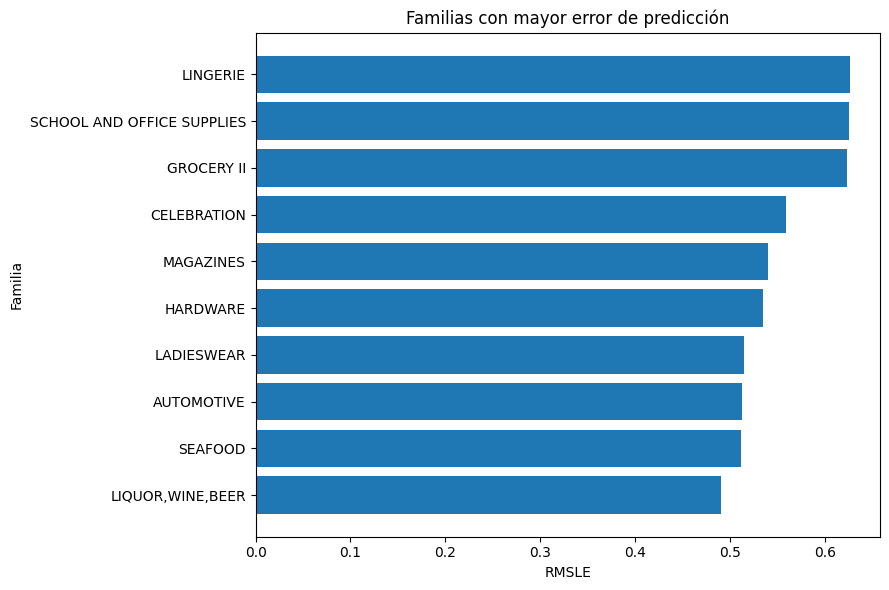

In [429]:
top_error_families = (
    family_error
    .head(10)
    .sort_values("RMSLE")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_error_families.index,
    top_error_families["RMSLE"]
)

plt.title(
    "Familias con mayor error de predicción"
)
plt.xlabel("RMSLE")
plt.ylabel("Familia")

plt.tight_layout()
plt.show()

**Interpretación:** El desempeño del modelo no es homogéneo entre categorías. Algunas familias presentan patrones de demanda más difíciles de anticipar, por lo que el RMSLE global debe complementarse con métricas por segmento.

In [430]:
family_comparison = (
    validation_results[
        ["family", "sales", "prediction"]
    ]
    .copy()
)

family_comparison["baseline"] = (
    valid_ml["sales_lag_21"]
    .to_numpy()
)

family_model_results = []

for family, group in family_comparison.groupby(
    "family"
):

    baseline_family_rmsle = np.sqrt(
        mean_squared_log_error(
            group["sales"],
            group["baseline"].clip(lower=0)
        )
    )

    xgb_family_rmsle = np.sqrt(
        mean_squared_log_error(
            group["sales"],
            group["prediction"]
        )
    )

    family_model_results.append({
        "family": family,
        "baseline_RMSLE": baseline_family_rmsle,
        "XGBoost_RMSLE": xgb_family_rmsle
    })

family_model_comparison = pd.DataFrame(
    family_model_results
)

family_model_comparison[
    "improvement_pct"
] = (
    (
        family_model_comparison[
            "baseline_RMSLE"
        ]
        -
        family_model_comparison[
            "XGBoost_RMSLE"
        ]
    )
    /
    family_model_comparison[
        "baseline_RMSLE"
    ]
    * 100
)

print(
    "Familias donde XGBoost supera al baseline:",
    (
        family_model_comparison[
            "XGBoost_RMSLE"
        ]
        <
        family_model_comparison[
            "baseline_RMSLE"
        ]
    ).sum(),
    "de",
    len(family_model_comparison)
)

Familias donde XGBoost supera al baseline: 31 de 33


In [431]:
display(
    family_model_comparison[
        family_model_comparison[
            "XGBoost_RMSLE"
        ]
        >=
        family_model_comparison[
            "baseline_RMSLE"
        ]
    ].sort_values("improvement_pct")
)

,family,baseline_RMSLE,XGBoost_RMSLE,improvement_pct
30,PRODUCE,0.189283,0.192689,-1.799607
5,BREAD/BAKERY,0.220695,0.223421,-1.235148


### Conclusiones del análisis de errores

XGBoost supera al baseline estacional en **31 de las 33 familias de productos**, mostrando que la mejora del modelo se extiende a la gran mayoría de las categorías y no se concentra únicamente en algunos segmentos.

Las únicas excepciones son `PRODUCE` y `BREAD/BAKERY`, donde el baseline obtiene una ventaja pequeña.

También se observan diferencias relevantes en el nivel de error entre familias, lo que evidencia la importancia de evaluar el forecasting a nivel de segmento además de utilizar una métrica global.

Se evaluó conceptualmente la posibilidad de combinar modelos según familia, pero la mejora obtenida era marginal frente al aumento de complejidad. Por ello se mantiene XGBoost como modelo único.

## 13. Entrenamiento del modelo final

### Entrenamiento con todo el historial disponible

Una vez seleccionado XGBoost mediante validación temporal y backtesting, el modelo final se entrena utilizando todo el historial disponible hasta el **15 de agosto de 2017**.

Las variables históricas mantienen las mismas restricciones utilizadas durante la validación, de modo que todas ellas estén disponibles para los 16 días del horizonte futuro.

In [432]:
train_final = df.dropna(
    subset=required_features
).copy()

X_train_final = train_final[
    feature_columns
].copy()

y_train_final = train_final[
    "sales"
].copy()

print(
    "Entrenamiento final:",
    X_train_final.shape
)

print(
    "Última fecha:",
    train_final["date"].max()
)

Entrenamiento final: (2929608, 22)
Última fecha: 2017-08-15 00:00:00


In [433]:
df_test_model = df_test.merge(
    df_stores,
    on="store_nbr",
    how="left"
)

# Features de calendario
df_test_model["year"] = df_test_model["date"].dt.year
df_test_model["month"] = df_test_model["date"].dt.month
df_test_model["day"] = df_test_model["date"].dt.day
df_test_model["day_of_week"] = (
    df_test_model["date"].dt.dayofweek
)

df_test_model["week_of_year"] = (
    df_test_model["date"]
    .dt.isocalendar()
    .week
    .astype("int16")
)

df_test_model["is_weekend"] = (
    df_test_model["day_of_week"]
    .isin([5, 6])
    .astype("int8")
)

In [434]:
df_test_model["national_event"] = (
    df_test_model["date"]
    .isin(national_dates)
    .astype("int8")
)

df_test_model["regional_event"] = [
    int((date, state) in regional_keys)
    for date, state in zip(
        df_test_model["date"],
        df_test_model["state"]
    )
]

df_test_model["local_event"] = [
    int((date, city) in local_keys)
    for date, city in zip(
        df_test_model["date"],
        df_test_model["city"]
    )
]

df_test_model["is_event"] = (
    (df_test_model["national_event"] == 1) |
    (df_test_model["regional_event"] == 1) |
    (df_test_model["local_event"] == 1)
).astype("int8")

In [435]:
df_test_model = df_test_model.merge(
    oil_daily,
    on="date",
    how="left"
)

In [436]:
for lag in [16, 21, 28]:

    lag_df = df_train[
        ["date", "store_nbr", "family", "sales"]
    ].copy()

    lag_df["date"] = (
        lag_df["date"]
        + pd.Timedelta(days=lag)
    )

    lag_df = lag_df.rename(
        columns={
            "sales": f"sales_lag_{lag}"
        }
    )

    df_test_model = df_test_model.merge(
        lag_df,
        on=["date", "store_nbr", "family"],
        how="left"
    )

In [437]:
full_date_range = pd.date_range(
    df_train["date"].min(),
    df_test["date"].max(),
    freq="D"
)

sales_calendar_test = (
    df_train
    .set_index(
        ["date", "store_nbr", "family"]
    )["sales"]
    .unstack(["store_nbr", "family"])
    .reindex(full_date_range)
)

sales_calendar_test.index.name = "date"

rolling_test = (
    sales_calendar_test
    .rolling(
        window=28,
        min_periods=1
    )
    .mean()
    .shift(16)
)

rolling_test = (
    rolling_test
    .stack(
        ["store_nbr", "family"],
        future_stack=True
    )
    .rename("rolling_mean_28_lag16")
    .reset_index()
)

rolling_test = rolling_test[
    rolling_test["date"].between(
        df_test["date"].min(),
        df_test["date"].max()
    )
]

df_test_model = df_test_model.merge(
    rolling_test,
    on=["date", "store_nbr", "family"],
    how="left"
)

In [438]:
X_test_final = df_test_model[
    feature_columns
].copy()

print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)

print(
    "Nulos train:",
    X_train_final.isnull().sum().sum()
)

print(
    "Nulos test:",
    X_test_final.isnull().sum().sum()
)

assert len(X_test_final) == len(df_test)
assert X_train_final.isnull().sum().sum() == 0
assert X_test_final.isnull().sum().sum() == 0

print("\n✓ Controles superados")

Train: (2929608, 22)
Test: (28512, 22)
Nulos train: 0
Nulos test: 0

✓ Controles superados


In [439]:
final_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_final[categorical_features] = (
    final_encoder.fit_transform(
        X_train_final[categorical_features]
    )
)

X_test_final[categorical_features] = (
    final_encoder.transform(
        X_test_final[categorical_features]
    )
)

In [440]:
final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

final_model.fit(
    X_train_final,
    np.log1p(y_train_final)
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

## 14. Predicción de demanda

In [441]:
test_predictions = np.clip(
    np.expm1(
        final_model.predict(
            X_test_final
        )
    ),
    0,
    None
)

print(
    "Predicciones:",
    len(test_predictions)
)

print(
    "Promedio:",
    round(test_predictions.mean(), 2)
)

print(
    "Mínimo:",
    round(test_predictions.min(), 2)
)

print(
    "Máximo:",
    round(test_predictions.max(), 2)
)

Predicciones: 28512
Promedio: 435.99
Mínimo: 0.0
Máximo: 14214.62


In [442]:
submission = pd.DataFrame({
    "id": df_test["id"],
    "sales": test_predictions
})

assert submission["id"].equals(
    sample_submission["id"]
)

assert submission.isnull().sum().sum() == 0
assert submission["id"].duplicated().sum() == 0
assert (submission["sales"] < 0).sum() == 0

print("Submission:", submission.shape)
print("✓ IDs correctamente alineados")
print("✓ Sin valores nulos")
print("✓ Sin IDs duplicados")
print("✓ Sin predicciones negativas")

Submission: (28512, 2)
✓ IDs correctamente alineados
✓ Sin valores nulos
✓ Sin IDs duplicados
✓ Sin predicciones negativas


### Evaluación externa

La predicción final fue evaluada en la competencia **Store Sales - Time Series Forecasting** de Kaggle.

**Public Score obtenido: 0,50663 RMSLE.**

El resultado externo es inferior al RMSLE promedio obtenido durante el backtesting (0,4004), evidenciando una degradación al evaluar un período completamente futuro. Esta diferencia refuerza la importancia de complementar la validación histórica con evaluaciones fuera de muestra y evitar interpretar las métricas de validación como garantía de desempeño futuro.

## 15. Resultados y conclusiones

## 15. Resultados y conclusiones

### Resultados principales

El proyecto desarrolló un pipeline completo de forecasting de demanda utilizando más de **3 millones de observaciones históricas**, correspondientes a 54 tiendas y 33 familias de productos.

Se compararon tres enfoques principales:

| Modelo | RMSLE validación | Mejora vs. baseline |
|---|---:|---:|
| Seasonal Naive (lag 21) | 0,6330 | — |
| Random Forest | 0,4329 | 31,61% |
| **XGBoost** | **0,4110** | **35,07%** |

XGBoost obtuvo el mejor desempeño y fue seleccionado como modelo final.

El backtesting mediante cuatro ventanas temporales consecutivas mostró un **RMSLE promedio de 0,4004**, frente a **0,5595** del baseline, equivalente a una mejora promedio aproximada del **28,13%**.

Además, XGBoost superó al baseline en **31 de las 33 familias de productos** analizadas.

La predicción final generó **28.512 forecasts** correspondientes a un horizonte futuro de 16 días. La evaluación externa en Kaggle obtuvo un **Public Score de 0,50663 RMSLE**.

### Implicancias para Supply Chain

Los resultados muestran que la demanda presenta patrones temporales y comerciales que pueden ser aprovechados mediante Machine Learning.

Entre los principales hallazgos:

- Existe una marcada estacionalidad semanal, con mayores niveles de venta durante los fines de semana.
- Las promociones contienen información relevante para anticipar cambios en la demanda.
- El comportamiento histórico reciente constituye la principal fuente de información predictiva del modelo.
- Existen diferencias importantes entre familias de productos, por lo que el desempeño del forecast debe analizarse también a nivel de segmento.
- Un forecast más preciso puede apoyar procesos de planificación de inventarios, reposición y abastecimiento, reduciendo el riesgo de quiebres de stock y exceso de inventario.

### Decisiones metodológicas relevantes

Durante el desarrollo se tomaron varias decisiones orientadas a mantener un escenario de forecasting realista:

- Se utilizó validación cronológica en lugar de una división aleatoria de los datos.
- El horizonte de validación se fijó en 16 días para reproducir el horizonte real de predicción.
- No se utilizaron las transacciones del mismo día como predictor, debido a que no estarían disponibles al momento de realizar un forecast futuro.
- Los lags se construyeron utilizando días calendario y no posiciones de filas.
- Se utilizaron lags de 16, 21 y 28 días para garantizar que las variables históricas estuvieran disponibles durante todo el horizonte.
- La media móvil histórica fue desplazada 16 días para evitar data leakage.
- Se utilizó backtesting temporal para comprobar la estabilidad del modelo en múltiples períodos.

### Limitaciones

El proyecto presenta algunas limitaciones que deberían considerarse antes de implementar un sistema similar en producción:

- El comportamiento de la demanda puede cambiar entre períodos, como evidencia la diferencia entre el backtesting y el Public Score de Kaggle.
- Algunas familias presentan demanda intermitente y mayores niveles de error.
- El precio futuro del petróleo está disponible en el contexto de la competencia, pero su disponibilidad debería evaluarse en un escenario productivo real.
- La codificación ordinal de variables categóricas fue utilizada principalmente por eficiencia computacional sobre un dataset de más de 3 millones de registros.
- El modelo estima demanda, pero el proyecto no incorpora todavía restricciones operacionales como inventario disponible, lead time, capacidad logística o nivel de servicio.

### Conclusión

El proyecto demuestra que un modelo de Machine Learning puede superar de forma consistente una estrategia estacional sencilla de forecasting cuando se incorporan adecuadamente información histórica, calendario, promociones y características de los establecimientos.

Más allá del desempeño predictivo, el principal foco metodológico fue construir un proceso reproducible y evitar el uso de información que no estaría disponible al momento de realizar una predicción real.

El resultado es un pipeline completo que abarca desde la exploración de datos y la ingeniería de variables hasta la validación temporal, backtesting, análisis de errores y generación del forecast final.